# Physics for Scientists & Engineers

<img src="..//pics/cover.jpg" width=400> 


In [2]:
import setuptools

print("setuptools version:", setuptools.__version__)  # Should be < 70.0.0

import vpython as vp
from astropy import units as u
from astropy import constants as const
import sympy as sp
import numpy as np
from IPython.display import display, Math
import matplotlib.pyplot as plt
import sys
from pathlib import Path

print("All imports succeeded!")

setuptools version: 69.5.1


<IPython.core.display.Javascript object>

All imports succeeded!


In [30]:
!python --version

Python 3.12.10


In [31]:
pwd


'c:\\Users\\crodr\\BK_tech\\Physics\\BK_Physics_4_SE_Serway_11\\ch05'

### Problems
#### Section 5 Additional Problems
#### Problem 37

page 138

<!-- <img src="..//pics/FigP5_15.png" width=400>  -->

A black aluminum glider floats on a film of air above
a level aluminum air track. Aluminum feels essentially
no force in a magnetic field, and air resistance is negligible.
A strong magnet is attached to the top of the
glider, forming a total mass of 240 g. A piece of scrap
iron attached to one end stop on the track attracts the
magnet with a force of 0.823 N when the iron and the
magnet are separated by 2.50 cm. 

**(a)** Find the acceleration
of the glider at this instant. 

**(b)** The scrap iron is
now attached to another green glider, forming total mass
120 g. Find the acceleration of each glider when the gliders
are simultaneously released at 2.50-cm separation.




In [5]:
# 1. Define symbolic variables
m1, m2, F = sp.symbols("m1 m2 F", positive=True)
a1_a, a1_b, a2_b = sp.symbols("a1_a a1_b a2_b", real=True)

# 2. Equations of motion based on Newton's Second Law
eq_a = sp.Eq(F, m1 * a1_a)
eq_b_m1 = sp.Eq(F, m1 * a1_b)
eq_b_m2 = sp.Eq(F, m2 * a2_b)

# 3. Solve for accelerations symbolically
sol_a1_a = sp.solve(eq_a, a1_a)[0]
sol_a1_b = sp.solve(eq_b_m1, a1_b)[0]
sol_a2_b = sp.solve(eq_b_m2, a2_b)[0]

# 4. Display expressions using Jupyter's native LaTeX renderer
display(
    Math(r"\text{\textbf{Part (a) Acceleration of Black Glider (Fixed Scrap Iron):}}")
)
display(sp.Eq(a1_a, sol_a1_a))

display(
    Math(r"\text{\textbf{Part (b) Acceleration of Black Glider (Free Scrap Iron):}}")
)
display(sp.Eq(a1_b, sol_a1_b))

display(
    Math(r"\text{\textbf{Part (b) Acceleration of Green Glider (Free Scrap Iron):}}")
)
display(sp.Eq(a2_b, sol_a2_b))

<IPython.core.display.Math object>

Eq(a1_a, F/m1)

<IPython.core.display.Math object>

Eq(a1_b, F/m1)

<IPython.core.display.Math object>

Eq(a2_b, F/m2)

In [28]:
# 1. Convert SymPy expressions to callable functions using lambdify
func_a1_a = sp.lambdify((F, m1), sol_a1_a, "numpy")
func_a1_b = sp.lambdify((F, m1), sol_a1_b, "numpy")
func_a2_b = sp.lambdify((F, m2), sol_a2_b, "numpy")

# 2. Define real value variables with Astropy units
m1_val = 240 * u.g
m2_val = 120 * u.g
F_val = 0.823 * u.N

# 3. Evaluate numerical values with Quantity inputs directly
acc_part_a = func_a1_a(F_val.to(u.N), m1_val.to(u.kg))
acc_part_b_m1 = func_a1_b(F_val.to(u.N), m1_val.to(u.kg))
acc_part_b_m2 = func_a2_b(F_val.to(u.N), m2_val.to(u.kg))

print(f"(a) a_{{1,a}} = {acc_part_a.to(u.m / u.s**2):.2f}")
print(f"(b) a_{{1,b}} = {acc_part_b_m1.to(u.m / u.s**2):.2f}")
print(f"(b) a_{{2,b}} = {acc_part_b_m2.to(u.m / u.s**2):.2f}")


(a) a_{1,a} = 3.43 m / s2
(b) a_{1,b} = 3.43 m / s2
(b) a_{2,b} = 6.86 m / s2


#### Problem 41

page 139

<img src="..//pics/FigP5_41.png" width=400> 

An inventive child named Greyson wants to reach an
apple in a tree without climbing the tree. Sitting in a
chair connected to a rope that passes over a frictionless
pulley (Fig. P5.41), Greyson pulls on the loose end of the
rope with such a force that the spring scale reads 250 N.
Greyson’s true weight is 320 N, and the chair weighs 160
N. Greyson’s feet are not touching the ground. 

**(a)** Draw one pair of diagrams showing the forces for Greyson
and the chair considered as separate systems and
another diagram for Greyson and the chair considered
as one system. 

**(b)** Show that the acceleration of the
system is upward and find its magnitude.




(a) Diagrams

<img src="..//pics/FigP5_41_2.png" width=400> 




In [ ]:
# 1. Define symbolic variables
Fg1, Fg2, T, g = sp.symbols("Fg1 Fg2 T g", positive=True)
a, n = sp.symbols("a n", real=True)

# 2. Define masses and total weight
m1 = Fg1 / g
m2 = Fg2 / g
m_tot = m1 + m2
Fg_tot = Fg1 + Fg2

# 3. Equations of motion
eq_acc = sp.Eq(2 * T - Fg_tot, m_tot * a)
eq_norm = sp.Eq(T + n - Fg2, m2 * a)

# 4. Solve symbolically
sol_a = sp.solve(eq_acc, a)[0]
sol_n = sp.solve(eq_norm.subs(a, sol_a), n)[0]

# 5. Display symbolic results using LaTeX
display(Math(r"\text{\textbf{Part (b) Acceleration of the System (a):}}"))
display(sp.Eq(a, sol_a))

display(Math(r"\text{\textbf{Part (c) Force Greyson Exerts on Chair (n):}}"))
display(sp.Eq(n, sol_n))

<IPython.core.display.Math object>

Eq(a, g*(-Fg1 - Fg2 + 2*T)/(Fg1 + Fg2))

<IPython.core.display.Math object>

Eq(n, T*(-Fg1 + Fg2)/(Fg1 + Fg2))

In [ ]:
# 1. Convert SymPy expressions to callable functions using lambdify
func_a = sp.lambdify((Fg1, Fg2, T, g), sol_a, "numpy")
func_n = sp.lambdify((Fg1, Fg2, T), sol_n, "numpy")

# 2. Define real value variables with Astropy units
Fg1_val = 160 * u.N
Fg2_val = 320 * u.N
T_val = 250 * u.N
g_val = const.g0  # Standard gravity (~9.80665 m/s^2)

# 3. Evaluate numerical values directly passing Astropy quantities
acc_val = func_a(
    Fg1_val.to(u.N), Fg2_val.to(u.N), T_val.to(u.N), g_val.to(u.m / u.s**2)
)
norm_val = func_n(Fg1_val.to(u.N), Fg2_val.to(u.N), T_val.to(u.N))

# 4. Print clean formatted output
target_unit_acc = u.m / u.s**2
target_unit_force = u.N

print(f"(b) Acceleration of system = {acc_val.to(target_unit_acc):.3f}")
print(f"(c) Normal force on chair  = {norm_val.to(target_unit_force):.1f}")

(b) Acceleration of system = 0.409 m / s2
(c) Normal force on chair  = 83.3 N


#### Problem 47

page 140

You are working as an expert witness for the defense of
a container ship captain whose ship ran into a reef surrounding
a Caribbean island. The captain is being
charged with intentionally running the ship into the
reef. In discovery, the following information has been
presented, and attorneys on both sides have stipulated
that the information is correct: The ship was traveling
at 2.50 m/s toward the reef when a mechanical failure
caused the rudder to jam in the straight-ahead position.
At that point in time, the ship was 900 m from the reef.
The wind was blowing directly toward the reef, and
exerting a constant force of $9.00 \times 10^3$ N on the ship in a
direction toward the reef. The mass of the ship and its
cargo was $5.50 \times 10^7$ kg. During the preparation for the
trial, the captain claims that without control of
the direction of travel, the only choice he had was to
put the engines in reverse at maximum power, such that
the total force exerted by the frictional drag force of the
water and the force of the water on the propellers was
$1.25 \times 10^5$ N in a direction away from the reef. From this
information, construct a convincing argument that
nothing the captain could do in this situation could
have prevented the ship from striking the reef.




In [ ]:
# 1. Define symbolic variables
v0, d_reef, F_wind, F_reverse, m = sp.symbols(
    "v0 d_reef F_wind F_reverse m", positive=True
)
a, d_stop = sp.symbols("a d_stop", real=True)

# 2. Net force and acceleration equations
# Taking direction toward reef as positive
F_net = F_wind - F_reverse
eq_acc = sp.Eq(a, F_net / m)

# Kinematic equation for stopping distance (vf = 0)
eq_kin = sp.Eq(0, v0**2 + 2 * a * d_stop)

# 3. Solve for acceleration and stopping distance symbolically
sol_a = sp.solve(eq_acc, a)[0]
sol_d_stop = sp.solve(eq_kin.subs(a, sol_a), d_stop)[0]

# 4. Display symbolic results using LaTeX
display(Math(r"\text{\textbf{Net Acceleration (a):}}"))
display(sp.Eq(a, sol_a))

display(Math(r"\text{\textbf{Minimum Stopping Distance }} (d_{\text{stop}}):"))
display(sp.Eq(d_stop, sol_d_stop))

<IPython.core.display.Math object>

Eq(a, (-F_reverse + F_wind)/m)

<IPython.core.display.Math object>

Eq(d_stop, m*v0**2/(2*(F_reverse - F_wind)))

In [ ]:
# 1. Convert SymPy expressions to callable functions using lambdify
func_a = sp.lambdify((v0, F_wind, F_reverse, m), sol_a, "numpy")
func_d_stop = sp.lambdify((v0, F_wind, F_reverse, m), sol_d_stop, "numpy")

# 2. Define real value variables with Astropy units
v0_val = 2.50 * (u.m / u.s)
d_reef_val = 900 * u.m
F_wind_val = 9.00e3 * u.N
F_reverse_val = 1.25e5 * u.N
m_val = 5.50e7 * u.kg

# 3. Evaluate numerical values directly passing Astropy quantities
a_val = func_a(v0_val, F_wind_val, F_reverse_val, m_val)
d_stop_val = func_d_stop(v0_val, F_wind_val, F_reverse_val, m_val)

# 4. Print clean formatted output
print(f"Deceleration = {a_val.to(u.m / u.s**2):.6f}")
print(f"Minimum Stopping Distance = {d_stop_val.to(u.m):,.1f}")
print(f"Distance Available to Reef = {d_reef_val.to(u.m):.1f}")
print("Striking the reef was physically inevitable.")

Deceleration = -0.002109 m / s2
Minimum Stopping Distance = 1,481.7 m
Distance Available to Reef = 900.0 m
Striking the reef was physically inevitable.


##### Simulation
$ python simulation_ch05_p47.py

#### Problem 48

page 140

<img src="..//pics/FigP5_48.png" width=300> 

A flat cushion of mass m is released from rest at  the corner of the roof of a building, at height h. A
wind blowing along the side of the building exerts a constant horizontal force of magnitude F on
the cushion as it drops as shown in Figure P5.48. The air exerts no vertical force.

**(a)** Show that the path of the cushion is a straight line. 

**(b)** Does the cushion fall with constant velocity? Explain. 

**(c)** If $m = 1.20 kg$, $h = 12.0 m$, and $F = 2.40 N $, how far from the building will the cushion
hit the level ground? What If? 

**(d)** If the cushion is thrown downward with a nonzero speed at the top of the building,
what will be the shape of its trajectory? Explain.

In [ ]:
# 1. Define symbolic variables
m, h, F, g, t, x, v0_y = sp.symbols("m h F g t x v0_y", positive=True)

# 2. Acceleration components
ax = F / m
ay = -g

# 3. Kinematics for Part (a) - Released from rest
x_t = sp.Rational(1, 2) * ax * t**2
y_t = h + sp.Rational(1, 2) * ay * t**2

# Solve for t**2 from x(t) and substitute into y(t)
t2_expr = sp.solve(sp.Eq(x, x_t), t**2)[0]
y_of_x = y_t.subs(t**2, t2_expr)

# 4. Landing distance for Part (c)
t_fall = sp.sqrt(2 * h / g)
d_landing = x_t.subs(t, t_fall)

# 5. Trajectory for Part (d) - Thrown downward with v0_y
y_t_down = h - v0_y * t + sp.Rational(1, 2) * ay * t**2
t_expr = sp.sqrt(2 * m * x / F)
y_of_x_down = y_t_down.subs(t, t_expr)

# Display symbolic results
display(Math(r"\text{\textbf{Part (a) Trajectory equation y(x) starting from rest:}}"))
display(sp.Eq(sp.Symbol("y"), y_of_x))

display(Math(r"\text{\textbf{Part (c) Landing distance from building (d):}}"))
display(sp.Eq(sp.Symbol("d"), d_landing))

display(
    Math(r"\text{\textbf{Part (d) Trajectory equation y(x) when thrown downward:}}")
)
display(sp.Eq(sp.Symbol("y"), y_of_x_down))

<IPython.core.display.Math object>

Eq(y, h - g*m*x/F)

<IPython.core.display.Math object>

Eq(d, F*h/(g*m))

<IPython.core.display.Math object>

Eq(y, h - g*m*x/F - sqrt(2)*sqrt(m)*v0_y*sqrt(x)/sqrt(F))

**Part (a)**: Show that the path of the cushion is a straight line

$\displaystyle y = h - \frac{g m x}{F}$

Since y is a linear function of x (of the form $y = -kx +h$), the trajectory is a traight line with slope 
$-mg / F$

**Part (b)**: Does the cushion fall with constant velocity?

**No**, the cushion does not fall with constant velocity. Both components of acceleration ($a_x = F/m$ and $a_y = -g$) are non-zero and constant. Therefore, both the horizontal and vertical speed components increase linearly with time ($v_x = a_x t$ and $v_y = -g t$), causing the total magnitude of velocity $v = \sqrt{v_x^2 + v_y^2}$ to increase continuously.

**Part (c)**: Landing distance from the building ($d$)

In [ ]:
# 1. Convert SymPy expression for landing distance to callable function using lambdify
func_d = sp.lambdify((F, h, m, g), d_landing, "numpy")

# 2. Define real value variables with Astropy units
m_val = 1.20 * u.kg
h_val = 12.0 * u.m
F_val = 2.40 * u.N
g_val = const.g0  # Standard gravity (~9.80665 m/s^2)

# 3. Evaluate numerical value directly passing Astropy quantities
d_val = func_d(F_val.to(u.N), h_val.to(u.m), m_val.to(u.kg), g_val.to(u.m / u.s**2))

# 4. Print clean formatted output
target_unit_dist = u.m

print(f"(c) Landing distance from building = {d_val.to(target_unit_dist):.2f}")

(c) Landing distance from building = 2.45 m


**Part (d)**: What If? Trajectory when thrown downward with a non-zero initial speed

If thrown vertically downward with an initial velocity $v_{0y} = -v_0$:

* Horizontal position: $x(t) = \frac{1}{2}\left(\frac{F}{m}\right) t^2 \implies t = \sqrt{\frac{2mx}{F}}$

* Vertical position: $y(t) = h - v_0 t - \frac{1}{2} g t^2$

Substituting $t = \sqrt{\frac{2mx}{F}}$ into $y(t)$:

$$y(x) = h - v_0 \sqrt{\frac{2m}{F}} \cdot \sqrt{x} - \left(\frac{mg}{F}\right) x$$

Because of the $\sqrt{x}$ term, the relationship between $y$ and $x$ is no longer linear. The trajectory forms a parabola (curved path).

In [ ]:
# 1. Define symbolic variables
m, g, theta = sp.symbols("m g theta", positive=True)

# 2. Derive expressions for Normal force (n) and Acceleration (a)
n_expr = m * g * sp.cos(theta)
a_expr = g * sp.sin(theta)

# 3. Display symbolic results using LaTeX
display(Math(r"\text{\textbf{Normal Force }} (n):"))
display(sp.Eq(sp.Symbol("n"), n_expr))

display(Math(r"\text{\textbf{Acceleration }} (a):"))
display(sp.Eq(sp.Symbol("a"), a_expr))

<IPython.core.display.Math object>

Eq(n, g*m*cos(theta))

<IPython.core.display.Math object>

Eq(a, g*sin(theta))

Angle (deg)  | Normal Force (N) | Acceleration (m/s^2)
--------------------------------------------------------
0            | 82.376         N | 0.000          m / s2
5            | 82.062         N | 0.855          m / s2
10           | 81.124         N | 1.703          m / s2
15           | 79.569         N | 2.538          m / s2
20           | 77.408         N | 3.354          m / s2
25           | 74.658         N | 4.144          m / s2
30           | 71.340         N | 4.903          m / s2
35           | 67.478         N | 5.625          m / s2
40           | 63.104         N | 6.304          m / s2
45           | 58.249         N | 6.934          m / s2
50           | 52.950         N | 7.512          m / s2
55           | 47.249         N | 8.033          m / s2
60           | 41.188         N | 8.493          m / s2
65           | 34.814         N | 8.888          m / s2
70           | 28.174         N | 9.215          m / s2
75           | 21.320         N | 9.472         

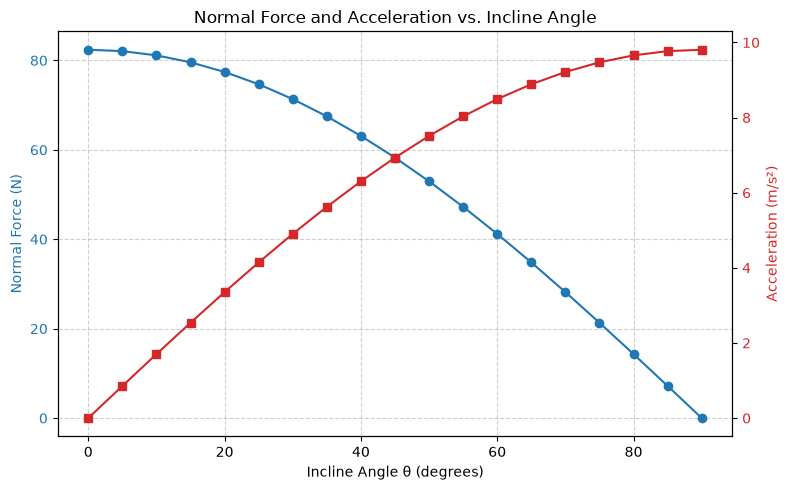

In [ ]:
# 1. Convert SymPy expressions to callable functions
func_n = sp.lambdify((m, g, theta), n_expr, "numpy")
func_a = sp.lambdify((g, theta), a_expr, "numpy")

# 2. Define real value variables with Astropy units
m_val = 8.40 * u.kg
g_val = const.g0  # Standard gravity (~9.80665 m/s^2)

# Incline angles from 0 to 90 degrees in 5-degree increments
angles_deg = np.arange(0, 95, 5) * u.deg
angles_rad = angles_deg.to(u.rad).value

# 3. Evaluate numerical values passing Astropy quantities
n_vals = func_n(m_val.to(u.kg), g_val.to(u.m / u.s**2), angles_rad)
a_vals = func_a(g_val.to(u.m / u.s**2), angles_rad)

# 4. Print tabulated results
print(f"{'Angle (deg)':<12} | {'Normal Force (N)':<16} | {'Acceleration (m/s^2)':<20}")
print("-" * 56)
for angle, n_i, a_i in zip(angles_deg, n_vals, a_vals):
    print(
        f"{angle.value:<12.0f} | {n_i.to(u.N):<14.3f} | {a_i.to(u.m / u.s**2):<14.3f}"
    )

# 5. Plotting (c)
fig, ax1 = plt.subplots(figsize=(8, 5))

color = "tab:blue"
ax1.set_xlabel("Incline Angle θ (degrees)")
ax1.set_ylabel("Normal Force (N)", color=color)
ax1.plot(
    angles_deg.value, n_vals.value, color=color, marker="o", label="Normal Force (n)"
)
ax1.tick_params(axis="y", labelcolor=color)
ax1.grid(True, linestyle="--", alpha=0.6)

ax2 = ax1.twinx()
color = "tab:red"
ax2.set_ylabel("Acceleration (m/s²)", color=color)
ax2.plot(
    angles_deg.value, a_vals.value, color=color, marker="s", label="Acceleration (a)"
)
ax2.tick_params(axis="y", labelcolor=color)

plt.title("Normal Force and Acceleration vs. Incline Angle")
fig.tight_layout()
plt.show()